# Plot neuron locations

Load neuron locations exported via `NeuronGroup::save_neuron_locations` and plot the excitatory group as scatter points.

In [5]:
from pathlib import Path
import csv
import matplotlib.pyplot as plt
import numpy as np

from utils import graphics
from buryn_utils import location_utils

graphics.set_matplotlib_settings()

In [6]:
BURYNOUTPUTS_DIR = '../data/buryn_data/buryn_outputs_01'
LOCATIONS_PATH_E = Path(BURYNOUTPUTS_DIR+'/locations/group_e_locations.txt')
LOCATIONS_PATH_I = Path(BURYNOUTPUTS_DIR+'/locations/group_i_locations.txt')
SELECTED_NEURON_IDS = [1029, 1070, 1071, 1124, 1228, 1274, 1324, 1328, 1373, 1429]

In [7]:
group_e_neuron_ids, group_e_neuron_locations = location_utils.load_neuron_locations(LOCATIONS_PATH_E)
group_i_neuron_ids, group_i_neuron_locations = location_utils.load_neuron_locations(LOCATIONS_PATH_I)

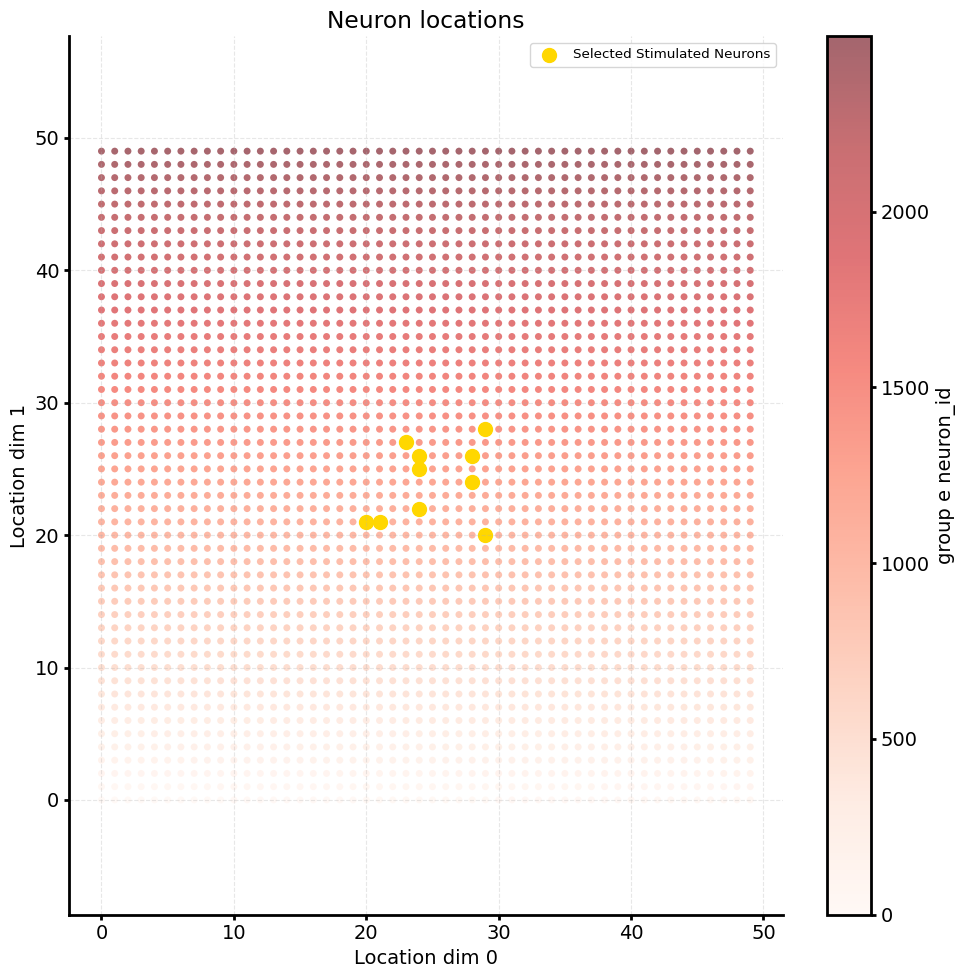

In [15]:
plt.figure(figsize=(10, 10))
group_e_scatter_points = plt.scatter(
    group_e_neuron_locations[:, 0],
    group_e_neuron_locations[:, 1],
    c=group_e_neuron_ids,
    cmap="Reds",
    s=25,
    alpha=0.6,
    edgecolors="none",
)
# group_i_scatter_points = plt.scatter(
#     group_i_neuron_locations[:, 0],
#     group_i_neuron_locations[:, 1],
#     c=group_i_neuron_ids,
#     cmap="Blues",
#     s=25,
#     alpha=0.6,
#     edgecolors="none",
# )
plt.colorbar(group_e_scatter_points, label="group e neuron_id")
# plt.colorbar(group_i_scatter_points, label="group e neuron_id")
# Plot selected neurons with a different marker
selected_neuron_locations = []
for neuron_id in SELECTED_NEURON_IDS:
    if neuron_id in group_e_neuron_ids:
        idx = np.where(group_e_neuron_ids == neuron_id)[0][0]
        selected_neuron_locations.append(group_e_neuron_locations[idx])
plt.scatter(
    [loc[0] for loc in selected_neuron_locations],
    [loc[1] for loc in selected_neuron_locations],
    c="gold",
    s=100,
    marker="o",
    label="Selected Stimulated Neurons",
)
plt.legend()
plt.title("Neuron locations")
plt.xlabel("Location dim 0")
plt.ylabel("Location dim 1")
plt.axis("equal")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()